
[pct_counts_mt (%) — 描述統計]
             train       test
count    32374.000  18616.000
mean         5.374      5.795
std          2.307      2.053
min          0.000      0.021
1%           0.743      1.406
5%           1.725      2.598
10%          2.302      3.217
25%          3.568      4.299
50%          5.372      5.679
75%          7.080      7.221
90%          8.564      8.682
95%          9.241      9.403
99%         10.030     10.210
max         10.968     11.458
> 5.0%       0.553      0.628
> 10.0%      0.011      0.019
> 20.0%      0.000      0.000


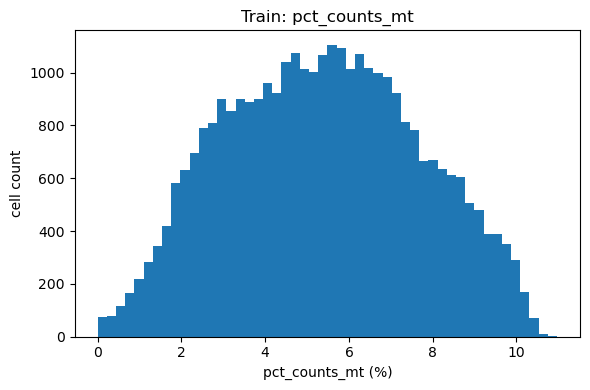

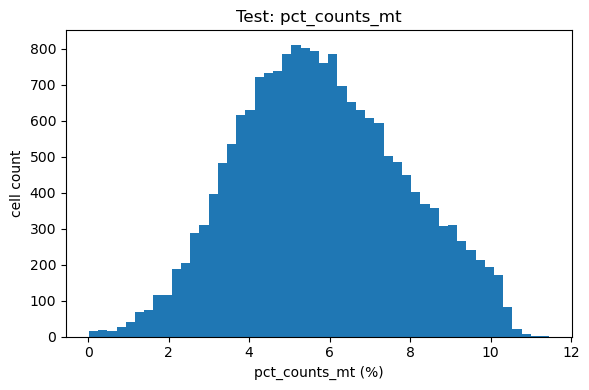

In [2]:
# ---- 放在你的腳本中，替換 basic_preprocess 的使用邏輯（先做 QC，不做任何過濾/正規化） ----

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

# 只計算 mt 百分比（在原始 counts 上），不做過濾/正規化
def compute_mt_qc_only(ad: sc.AnnData) -> np.ndarray:
    # 設定 mt gene mask
    vup = ad.var_names.str.upper()
    ad.var["mt"] = vup.str.startswith("MT-") | vup.str.startswith("MT_")
    # 在原始 ad.X 上計算 QC 指標（pct_counts_mt 介於 0~100）
    sc.pp.calculate_qc_metrics(ad, qc_vars=["mt"], inplace=True)
    return ad.obs["pct_counts_mt"].to_numpy()

def describe_pct_mt(arr: np.ndarray) -> pd.Series:
    s = pd.Series(arr)
    # 精細分位數 + 基本統計
    desc = s.describe(percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
    # 超過常用閾值的比例
    for thr in (5.0, 10.0, 20.0):
        desc[f"> {thr}%"] = float((s > thr).mean())
    return desc

def plot_hist_pct_mt(values: np.ndarray, title: str):
    plt.figure(figsize=(6,4))
    # 以 0~100% 的範圍畫直方圖（可調 bins）
    plt.hist(values, bins=50)
    plt.xlabel("pct_counts_mt (%)")
    plt.ylabel("cell count")
    plt.title(title)
    plt.tight_layout()

# ---------------- Load AnnData（沿用你的路徑變數） ----------------
ad_tr = sc.read_h5ad(TRAIN_AD_PATH)
ad_te = sc.read_h5ad(TEST_AD_PATH)

# ---------------- 只做 mt QC（不過濾） ----------------
pct_mt_tr = compute_mt_qc_only(ad_tr.copy())   # copy 防止改動原物件
pct_mt_te = compute_mt_qc_only(ad_te.copy())

# 描述統計表（train / test 並排）
stats_tbl = pd.DataFrame({
    "train": describe_pct_mt(pct_mt_tr),
    "test":  describe_pct_mt(pct_mt_te),
})
print("\n[pct_counts_mt (%) — 描述統計]")
print(stats_tbl.round(3).to_string())

# 兩邊直方圖（如不需要圖，註解掉）
plot_hist_pct_mt(pct_mt_tr, "Train: pct_counts_mt")
plot_hist_pct_mt(pct_mt_te, "Test: pct_counts_mt")
plt.show()

# ---------------- 之後才做你的 HVG/Harmony/正規化 ----------------
# 注意：QC 指標應基於 raw counts；正規化/對數轉換放在 QC 之後執行
# 例如：
# sc.pp.normalize_total(ad_tr, target_sum=1e4); sc.pp.log1p(ad_tr)
# sc.pp.normalize_total(ad_te, target_sum=1e4); sc.pp.log1p(ad_te)


In [27]:
# file: scripts/markers_autotune_per_ct.py
# -*- coding: utf-8 -*-
import numpy as np
import pandas as pd
from typing import Dict, List, Optional, Tuple
from itertools import product

EPS = 1e-9

# ----- AUROC（樣本層級，CT vs REST；只用 markers 的基因） -----
def auroc_ct_vs_rest(pb: pd.DataFrame, ct: str, genes: List[str]) -> float:
    """pb: genes x (Sample|CT)，返回該 ct 的 AUROC；無 scipy 版本（以秩和近似）。"""
    cols_ct = [c for c in pb.columns if c.split("|",1)[1] == ct]
    cols_rs = [c for c in pb.columns if c.split("|",1)[1] != ct]
    if not cols_ct or not cols_rs or len(genes)==0:
        return np.nan
    X_ct = pb.loc[pb.index.intersection(genes), cols_ct].mean(axis=0).to_numpy()
    X_rs = pb.loc[pb.index.intersection(genes), cols_rs].mean(axis=0).to_numpy()
    # 分數 = markers 的樣本均值（越大越像該 CT）
    y = np.r_[np.ones_like(X_ct), np.zeros_like(X_rs)]
    s = np.r_[X_ct, X_rs]
    # AUROC by rank
    order = np.argsort(s)
    ranks = np.empty_like(order); ranks[order] = np.arange(len(s))
    rank_sum_pos = ranks[:len(X_ct)].sum() if False else ranks[y==1].sum()
    n1 = float((y==1).sum()); n0 = float((y==0).sum())
    if n1==0 or n0==0: return np.nan
    # Mann–Whitney U -> ROC
    U = rank_sum_pos - n1*(n1-1)/2.0
    return float(U / (n1*n0))

# ----- 你先前的 imbalance-aware 選 marker（略微簡化，保留 FDR/weighted/test） -----
def contrast_topk_balanced(
    pb: pd.DataFrame,
    top_k: int,
    weights: Optional[pd.Series],
    use_median: bool,
    alpha: float
) -> Dict[str, List[str]]:
    from math import sqrt
    # 工具（沿用你前一版；此處省略檢定細節，保留接口）
    def _bh_fdr(p):
        p = np.asarray(p, float); n=p.size
        order = np.argsort(p); ranks = np.empty(n,int); ranks[order]=np.arange(1,n+1)
        q = p*n/ranks; qs = np.minimum.accumulate(q[order][::-1])[::-1]
        out = np.empty_like(qs); out[order]=np.clip(qs,0,1); return out

    def _weighted_mean_var(x,w):
        w = np.asarray(w,float); x=np.asarray(x,float)
        w = np.where(np.isfinite(w)&(w>0), w, 0.0)
        if w.sum()<=0 or x.size==0: return np.nan,np.nan,0.0
        m = np.average(x, weights=w); v = np.average((x-m)**2, weights=w)
        n_eff = (w.sum()**2)/(np.sum(w**2)+EPS); v = v*n_eff/max(n_eff-1.0,1.0)
        return float(m), float(v), float(n_eff)

    def _weighted_welch_t(x1,w1,x2,w2):
        m1,v1,n1 = _weighted_mean_var(x1,w1); m2,v2,n2 = _weighted_mean_var(x2,w2)
        if not (np.isfinite(m1)&np.isfinite(m2)&np.isfinite(v1)&np.isfinite(v2)&(n1>1)&(n2>1)): return np.nan,np.nan
        se = np.sqrt(v1/max(n1,EPS)+v2/max(n2,EPS)); 
        if not np.isfinite(se) or se<=0: return np.nan,np.nan
        t=(m1-m2)/se; a=v1/max(n1,EPS); b=v2/max(n2,EPS)
        df=(a+b)**2/((a**2)/max(n1-1.0,EPS)+(b**2)/max(n2-1.0,EPS)); return float(t), float(df)

    def _pt_two_sided(t,df):
        t=np.asarray(t,float); df=np.asarray(df,float); p=np.ones_like(t)
        m = np.isfinite(t)&np.isfinite(df)&(df>0)
        if not np.any(m): return p
        tabs = np.abs(t[m])
        try:
            from scipy import stats
            p[m] = 2.0*stats.t.sf(tabs, df[m])
        except Exception:
            z = tabs/np.sqrt(2.0); p[m]=2.0*(0.5*np.erfc(z))
        return np.clip(p,0.0,1.0)

    # 準備
    all_cts = [c.split("|",1)[1] for c in pb.columns]
    cts = sorted(set(all_cts))
    cols_by_ct = {ct:[c for c in pb.columns if c.endswith("|"+ct)] for ct in cts}
    weights = weights.reindex(pb.columns).fillna(0.0).astype(float) if weights is not None else pd.Series(1.0, index=pb.columns)
    X = pb.to_numpy(float); genes = pb.index.astype(str)

    out={}
    for ct in cts:
        idx_ct = [pb.columns.get_loc(c) for c in cols_by_ct.get(ct,[])]
        idx_rs = [i for i in range(pb.shape[1]) if i not in idx_ct]
        if len(idx_ct)==0 or len(idx_rs)==0: out[ct]=[]; continue
        X_ct, X_rs = X[:,idx_ct], X[:,idx_rs]
        w_ct, w_rs = weights.iloc[idx_ct].to_numpy(), weights.iloc[idx_rs].to_numpy()

        # 效應量（CT）：
        if use_median:
            stat_ct = np.median(X_ct, axis=1)
        else:
            stat_ct = np.array([_weighted_mean_var(X_ct[i], w_ct)[0] for i in range(X_ct.shape[0])])

        # REST：macro across CT
        rest_cts = [r for r in cts if r!=ct]
        stats_rest=[]
        for r in rest_cts:
            rcols = cols_by_ct.get(r, [])
            if not rcols: continue
            ridx = [pb.columns.get_loc(c) for c in rcols]
            X_r = X[:,ridx]; w_r = weights.iloc[ridx].to_numpy()
            if use_median:
                stats_rest.append(np.median(X_r, axis=1))
            else:
                stats_rest.append(np.array([_weighted_mean_var(X_r[i], w_r)[0] for i in range(X_r.shape[0])]))
        if not stats_rest: out[ct]=[]; continue
        stat_rest_macro = np.mean(np.stack(stats_rest, axis=1), axis=1)
        log2fc = np.log2((stat_ct+EPS)/(stat_rest_macro+EPS))

        # 顯著性
        t = np.empty(X.shape[0], float); dfv=np.empty_like(t)
        for i in range(X.shape[0]):
            ti,dfi = _weighted_welch_t(X_ct[i], w_ct, X_rs[i], w_rs)
            t[i]=ti; dfv[i]=dfi
        p = _pt_two_sided(t,dfv); fdr=_bh_fdr(p)

        ok = fdr <= alpha
        order_idx = np.lexsort((-log2fc, -ok.astype(int)))
        out[ct] = genes[order_idx[:top_k]].tolist()
    return out

# ----- 調參器 -----
def autotune_markers_per_ct(
    pb: pd.DataFrame,
    base_markers: Dict[str, List[str]],
    weights: pd.Series,
    alpha_grid = (0.01, 0.02, 0.05, 0.1),
    topk_grid = (30, 50, 80),
    use_median_grid = (True, False),
    max_drop = 0.02  # 允許相對 baseline 的 AUROC 降幅上限
) -> Dict[str, List[str]]:
    # 先算 baseline per-CT AUROC
    base_auc = {ct: auroc_ct_vs_rest(pb, ct, genes) for ct, genes in base_markers.items()}
    tuned: Dict[str, List[str]] = {}

    for ct in sorted(base_markers.keys()):
        best_auc = -np.inf
        best_set: List[str] = base_markers[ct]
        target_min = (base_auc.get(ct) or 0.0) - max_drop
        for a, k, med in product(alpha_grid, topk_grid, use_median_grid):
            cand = contrast_topk_balanced(pb, top_k=k, weights=weights, use_median=med, alpha=a)
            genes = cand.get(ct, [])
            auc = auroc_ct_vs_rest(pb, ct, genes)
            if np.isnan(auc): continue
            # 兼顧最差不惡化：若 auc < target_min，跳過
            if auc < target_min: continue
            if auc > best_auc:
                best_auc = auc
                best_set = genes
        tuned[ct] = best_set
    return tuned


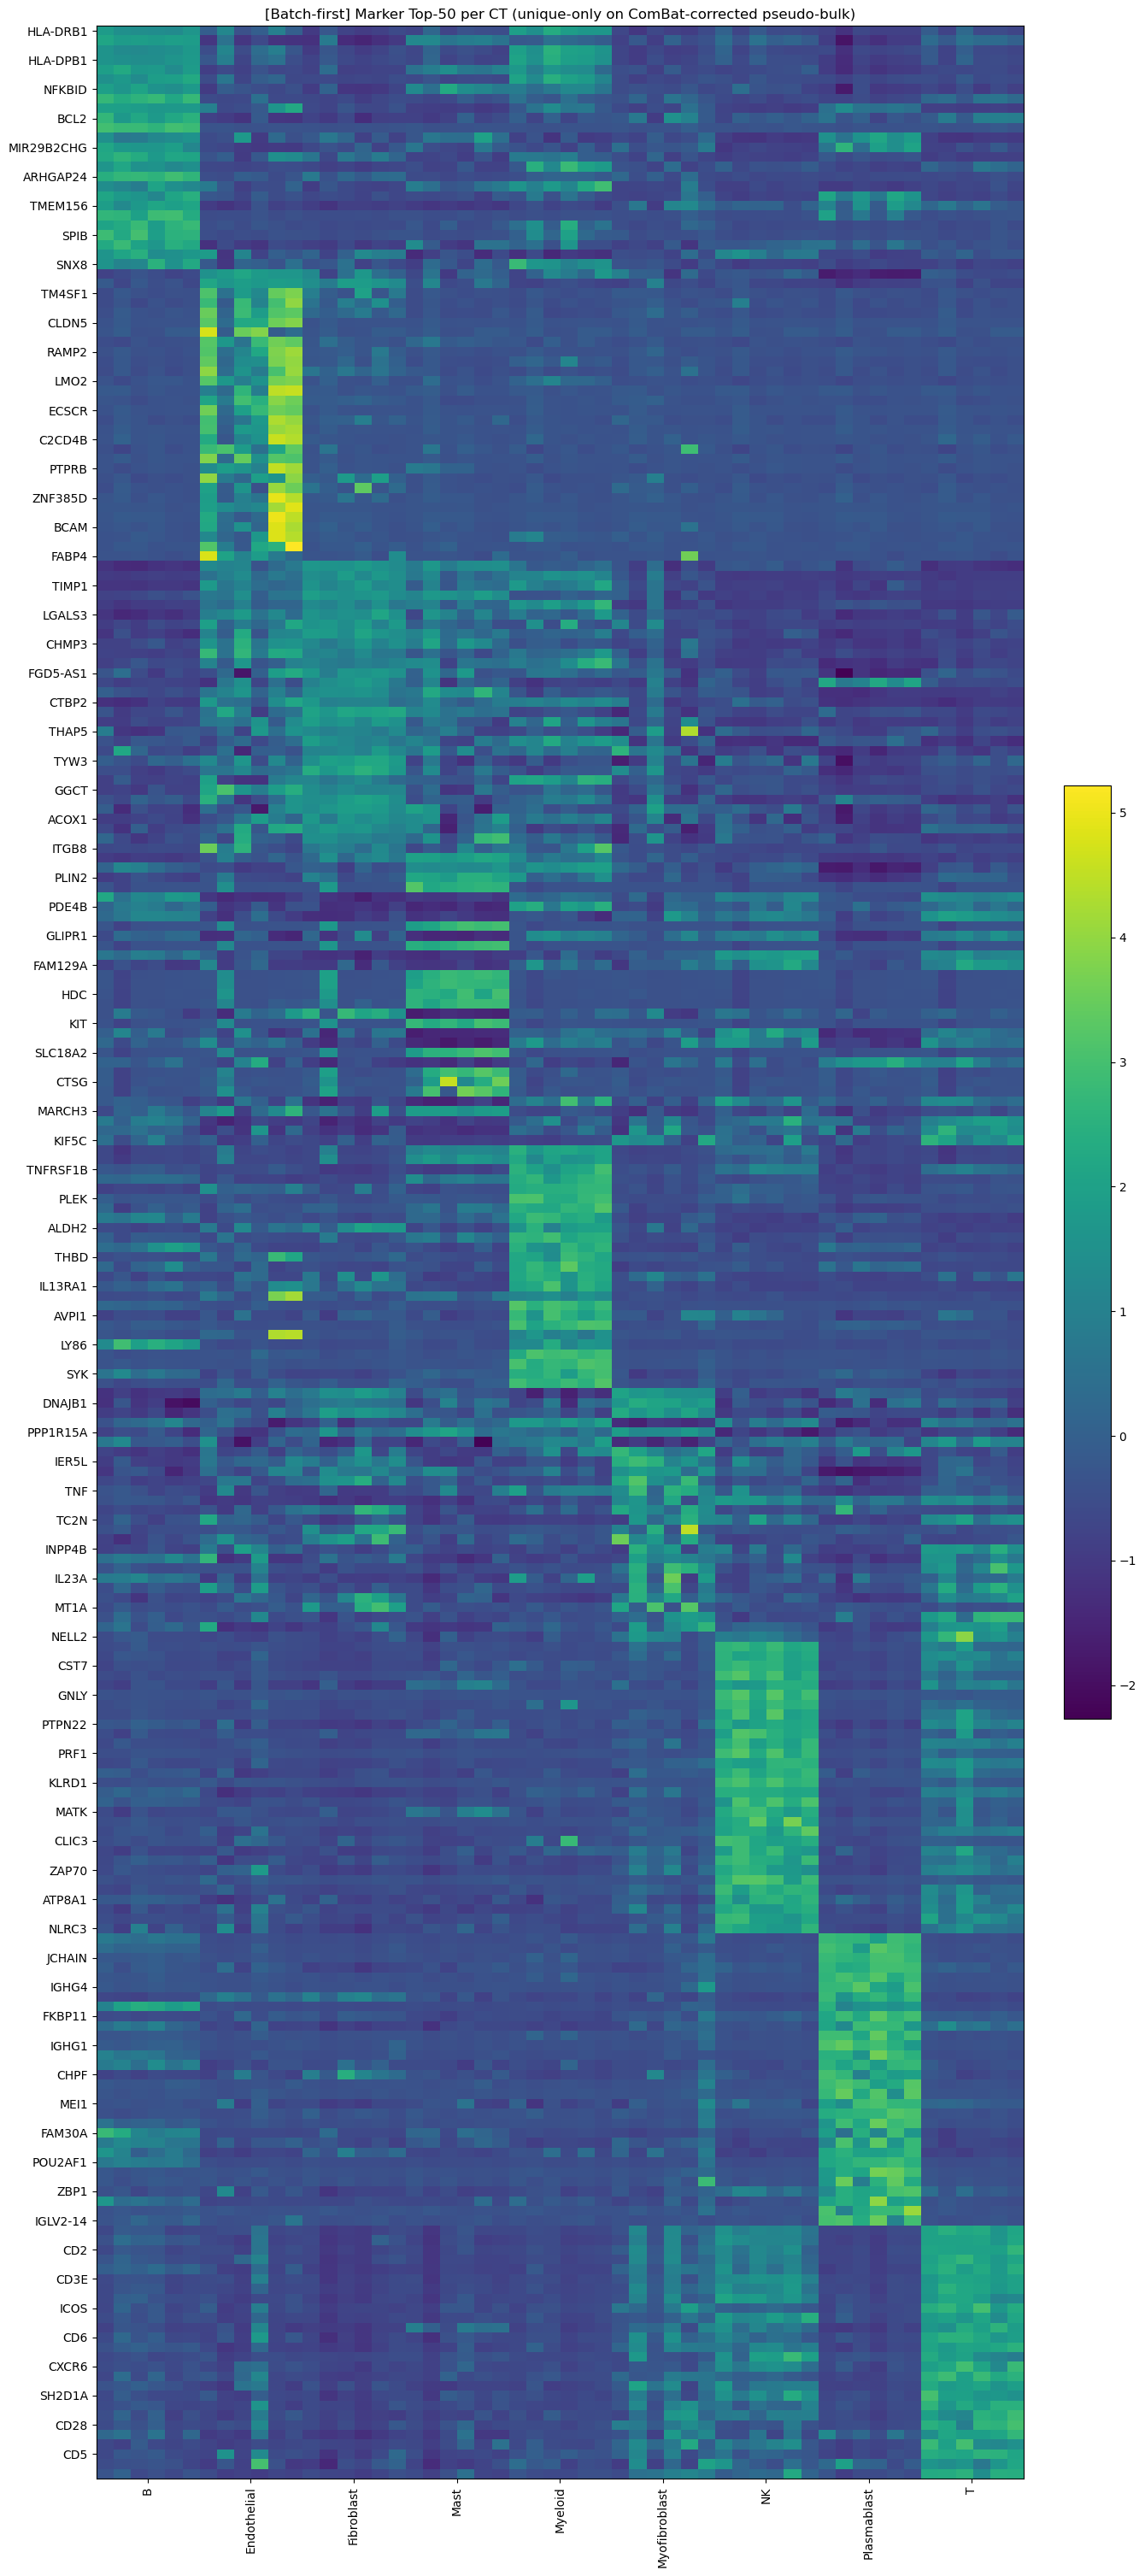

[CTs] ['B', 'Endothelial', 'Fibroblast', 'Mast', 'Myeloid', 'Myofibroblast', 'NK', 'Plasmablast', 'T']
[Removed cross-CT duplicates] 9 genes
  - B: kept 25 genes
  - Endothelial: kept 30 genes
  - Fibroblast: kept 30 genes
  - Mast: kept 30 genes
  - Myeloid: kept 25 genes
  - Myofibroblast: kept 26 genes
  - NK: kept 30 genes
  - Plasmablast: kept 30 genes
  - T: kept 26 genes
[Total rows plotted] 252


In [28]:
# Jupyter cell: Batch-first marker selection (on ComBat-corrected pseudo-bulk) → unique-only Top-50/CT → one big heatmap
AD_PATH       = r"../train_data/train_adata.h5ad"
CELLTYPE_COL  = "highLevelType"   # fallback: 'cell_type'
SAMPLE_COL    = "Sample"
TOP_K         = 50
USE_COMBAT    = True              # 先校正再選 marker：True 開啟 ComBat (batch=Sample)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------- helpers ----------------
def _need_scanpy():
    import scanpy as sc
    return sc

def _preprocess(adata):
    sc = _need_scanpy()
    sc.pp.filter_cells(adata, min_genes=200)
    sc.pp.filter_genes(adata, min_cells=3)
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)

def _pseudobulk_sample_ct(adata, ct_col: str, sample_col: str) -> pd.DataFrame:
    # genes × (sample|ct)
    obs = adata.obs[[ct_col, sample_col]].astype(str)
    groups = obs.groupby([sample_col, ct_col]).indices
    cols, names = [], []
    for (s, ct), idx in groups.items():
        X = adata.X[idx]
        cols.append(np.asarray(X.mean(axis=0)).ravel()); names.append(f"{s}|{ct}")
    return pd.DataFrame(np.column_stack(cols), index=adata.var_names.astype(str), columns=names)

def _combat(pb: pd.DataFrame) -> pd.DataFrame:
    # ComBat on pseudo-bulk (batch = Sample)
    sc = _need_scanpy()
    ad = sc.AnnData(pb.T.copy())
    ad.obs["batch"] = pd.Categorical([c.split("|",1)[0] for c in pb.columns])
    sc.pp.combat(ad, key="batch")
    return pd.DataFrame(ad.X.T, index=pb.index, columns=pb.columns)

def _contrast_topk(pb: pd.DataFrame, top_k: int) -> dict:
    """
    用已 batch-correct 的 pseudo-bulk 計對比分數：
      score(g, ct) = log2( mean_pb[g, ct] / mean_pb[g, rest] )
    取每個 CT 的 Top-K 基因；回傳 {ct: [genes...]}
    """
    cts = sorted({c.split("|",1)[1] for c in pb.columns})
    mean_all = pb.mean(axis=1) + 1e-9
    out = {}
    for ct in cts:
        cols_ct = [c for c in pb.columns if c.split("|",1)[1] == ct]
        if not cols_ct:
            out[ct] = []
            continue
        m_ct = pb[cols_ct].mean(axis=1)
        # rest = 加權方式：其他 CT 的均值（避免除以 0）
        rest = (mean_all * len(cts) - m_ct) / max(1e-12, (len(cts)-1))
        score = np.log2((m_ct + 1e-9) / (rest + 1e-9))
        out[ct] = list(score.sort_values(ascending=False).index[:top_k])
    return out

def _row_zscore(M: np.ndarray) -> np.ndarray:
    mu = M.mean(axis=1, keepdims=True)
    sd = M.std(axis=1, keepdims=True); sd[sd == 0] = 1.0
    return (M - mu) / sd

# ---------------- pipeline ----------------
sc = _need_scanpy()
adata = sc.read_h5ad(AD_PATH)
if CELLTYPE_COL not in adata.obs:
    if "cell_type" in adata.obs: CELLTYPE_COL = "cell_type"
    else: raise KeyError("Missing cell-type column (highLevelType/cell_type).")
if SAMPLE_COL not in adata.obs:
    raise KeyError("Missing 'Sample' column in adata.obs.")

_preprocess(adata)

# 1) pseudo-bulk
pb = _pseudobulk_sample_ct(adata, CELLTYPE_COL, SAMPLE_COL)

# 2) 先做 batch 校正（Sample 為 batch）
if USE_COMBAT:
    pb = _combat(pb)

# 3) 在校正後的 pseudo-bulk 上選 marker（CT vs rest, logFC Top-K/CT）
# 1) 先有 pb（可已做 ComBat）、weights（每個 Sample|CT 的 cell 數）
weights = (adata.obs[SAMPLE_COL].astype(str) + "|" + adata.obs[CELLTYPE_COL].astype(str)).value_counts()
weights = weights.reindex(pb.columns).fillna(0.0).astype(float)

# 2) 你的「第一版」marker（balanced 版或原版）
base_markers = contrast_topk_balanced(pb, top_k=TOP_K, weights=weights, use_median=True, alpha=0.05)

# 3) 自動為每個 CT 調 alpha/topK/統計型式，限制每個 CT 的 AUROC 不降超過 0.02
ct_to_top = autotune_markers_per_ct(
    pb, base_markers, weights,
    alpha_grid=(0.01,0.02,0.05,0.1),
    topk_grid=(30,50,80),
    use_median_grid=(True, False),
    max_drop=0.02
)

# 4) 之後照你原本流程（unique-only/heatmap）使用 tuned_markers 即可


# 4) 移除出現在 ≥2 個 CT Top-K 名單的基因（unique-only 規則）
from collections import Counter
gene_counts = Counter(g for genes in ct_to_top.values() for g in genes)
dup_genes = {g for g, n in gene_counts.items() if n >= 2}
ct_to_unique = {ct: [g for g in genes if g not in dup_genes] for ct, genes in ct_to_top.items()}

# 5) 欄排序（按 CT 分組），列排序（各 CT 的 unique genes 依全欄平均降冪，串接）
cts = sorted({c.split("|",1)[1] for c in pb.columns})
ct_to_cols = {ct: [c for c in pb.columns if c.split("|",1)[1] == ct] for ct in cts}
row_global_mean = pb.mean(axis=1)

row_order_concat = []
ct_sizes_kept = {}
for ct in cts:
    uniq = [g for g in ct_to_unique.get(ct, []) if g in pb.index]
    uniq_sorted = sorted(uniq, key=lambda g: row_global_mean.loc[g], reverse=True)
    if uniq_sorted:
        row_order_concat.extend(uniq_sorted)
    ct_sizes_kept[ct] = len(uniq_sorted)

if len(row_order_concat) == 0:
    raise ValueError("No genes remain after duplicate-removal; lower TOP_K or allow duplicates.")

ordered_cols, group_ticks, group_labels = [], [], []
pos = 0
for ct in cts:
    cols_ct = ct_to_cols[ct]
    if not cols_ct: continue
    ordered_cols.extend(cols_ct)
    group_ticks.append(pos + (len(cols_ct)-1)/2)
    group_labels.append(ct)
    pos += len(cols_ct)

M = pb.loc[row_order_concat, ordered_cols]
Z = _row_zscore(M.values)

# 6) 畫圖
plt.figure(figsize=(max(10, 0.25*M.shape[1]), max(6, 0.12*M.shape[0])))
im = plt.imshow(Z, aspect="auto")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(ticks=group_ticks, labels=group_labels, rotation=90)
if M.shape[0] <= 80:
    plt.yticks(ticks=np.arange(M.shape[0]), labels=M.index)
else:
    step = max(1, M.shape[0] // 80)
    plt.yticks(ticks=np.arange(0, M.shape[0], step), labels=M.index[0::step])
plt.title(f"[Batch-first] Marker Top-{TOP_K} per CT (unique-only on ComBat-corrected pseudo-bulk)")
plt.tight_layout(); plt.show()

# 7) 簡報
print(f"[CTs] {cts}")
print(f"[Removed cross-CT duplicates] {len(dup_genes)} genes")
for ct in cts:
    print(f"  - {ct}: kept {ct_sizes_kept.get(ct, 0)} genes")
print(f"[Total rows plotted] {len(row_order_concat)}")


In [20]:
M

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(120, 9))

In [ ]:
import os, warnings
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from typing import Dict, List

warnings.filterwarnings("ignore")

# ---------------- Config ----------------
TRAIN_AD_PATH = "../train_data/train_adata.h5ad"
TEST_AD_PATH  = "../test_data/test_adata.h5ad"

LABEL_COL      = "highLevelType"
SAMPLE_COL     = "Sample"
CT_COL         = "highLevelType"
BATCH_KEY_ALL  = "set"

TARGET_ORDER   = ["T","B","Endothelial","Fibroblast","Plasmablast","Myofibroblast","NK","Myeloid","Mast"]
N_TOP_HVG      = 3000
N_PCS          = 50
MARKER_TOPK_CT = 120
RANDOM_STATE   = 42

# ---------------- Utils ----------------
def _to_dense(X): return X.A if hasattr(X, "A") else np.asarray(X)

def basic_preprocess(ad: sc.AnnData) -> None:
    sc.pp.normalize_total(ad, target_sum=1e4)
    sc.pp.log1p(ad)

def pseudobulk_by_sample_ct(ad: sc.AnnData, ct_col: str, sample_col: str) -> pd.DataFrame:
    obs = ad.obs[[ct_col, sample_col]].astype(str)
    cols, names = [], []
    for (s, ct), idx in obs.groupby([sample_col, ct_col]).indices.items():
        Xi = _to_dense(ad.X[idx])
        cols.append(Xi.mean(axis=0).ravel()); names.append(f"{s}|{ct}")
    return pd.DataFrame(np.column_stack(cols), index=ad.var_names.astype(str), columns=names)

def combat_on_pb(pb: pd.DataFrame) -> pd.DataFrame:
    ad = sc.AnnData(pb.T.copy())
    ad.obs["batch"] = pd.Categorical([c.split("|",1)[0] for c in pb.columns])
    sc.pp.combat(ad, key="batch")
    return pd.DataFrame(ad.X.T, index=pb.index, columns=pb.columns)

def stratified_marker_by_ct(pb: pd.DataFrame, topk_per_ct: int, ct_order: List[str]) -> Dict[str, List[str]]:
    cts = sorted({c.split("|",1)[1] for c in pb.columns})
    order = [ct for ct in ct_order if ct in cts] + [ct for ct in cts if ct not in ct_order]
    mean_all = pb.mean(axis=1) + 1e-9
    out: Dict[str, List[str]] = {}
    denom = max(1, len(cts)-1)
    for ct in order:
        cols = [c for c in pb.columns if c.endswith("|"+ct)]
        if not cols:
            out[ct] = []; continue
        m_ct = pb[cols].mean(axis=1)
        rest = (mean_all * len(cts) - m_ct) / denom
        sc_ct = np.log2((m_ct+1e-9)/(rest+1e-9)).sort_values(ascending=False)
        out[ct] = list(sc_ct.index[:topk_per_ct])
    return out

def cosine_sim(A: np.ndarray, B: np.ndarray) -> np.ndarray:
    # A: (n, d), B: (m, d) -> (n, m)
    An = A / (np.linalg.norm(A, axis=1, keepdims=True) + 1e-9)
    Bn = B / (np.linalg.norm(B, axis=1, keepdims=True) + 1e-9)
    return An @ Bn.T

def imshow_heatmap(ax, M: np.ndarray, row_labels: List[str], col_labels: List[str], title: str, vmin=None, vmax=None):
    im = ax.imshow(M, aspect="auto", interpolation="nearest", vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(col_labels))); ax.set_xticklabels(col_labels, rotation=45, ha="right")
    ax.set_yticks(range(len(row_labels))); ax.set_yticklabels(row_labels)
    ax.set_title(title)
    cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    return im, cb

# ---------------- Load & preprocess ----------------
ad_tr = sc.read_h5ad(TRAIN_AD_PATH)
ad_te = sc.read_h5ad(TEST_AD_PATH)

if LABEL_COL not in ad_tr.obs or SAMPLE_COL not in ad_tr.obs or CT_COL not in ad_tr.obs:
    raise ValueError(f"Train AnnData.obs 需包含 {LABEL_COL}, {SAMPLE_COL}, {CT_COL}")

# basic_preprocess(ad_tr)
# basic_preprocess(ad_te)

# # ---------------- HVG=3000 on train+test, then Harmony ----------------
# adata_all = ad_tr.concatenate(ad_te, join="inner", batch_key=BATCH_KEY_ALL, batch_categories=["train","test"])
# sc.pp.highly_variable_genes(adata_all, n_top_genes=N_TOP_HVG, flavor="seurat_v3", batch_key=BATCH_KEY_ALL)
# adata_all = adata_all[:, adata_all.var["highly_variable"].values].copy()

# sc.pp.scale(adata_all, max_value=10)
# sc.tl.pca(adata_all, n_comps=min(N_PCS, adata_all.n_vars, adata_all.n_obs), svd_solver="arpack")
# sc.external.pp.harmony_integrate(adata_all, key=BATCH_KEY_ALL)  # -> X_pca_harmony
# if "X_pca_harmony" not in adata_all.obsm:
#     raise RuntimeError("Harmony failed (missing X_pca_harmony)")
# Z_harm = adata_all.obsm["X_pca_harmony"]

# # ---------------- Markers from TRAIN only ----------------
# ad_train_only = adata_all[adata_all.obs[BATCH_KEY_ALL]=="train"].copy()
# pb = pseudobulk_by_sample_ct(ad_train_only, ct_col=CT_COL, sample_col=SAMPLE_COL)
# pb = combat_on_pb(pb)
# markers_by_ct = stratified_marker_by_ct(pb, topk_per_ct=MARKER_TOPK_CT, ct_order=TARGET_ORDER)

# # restrict markers to HVG genes
# hvg_genes = set(adata_all.var_names.astype(str))
# for ct in list(markers_by_ct.keys()):
#     markers_by_ct[ct] = [g for g in markers_by_ct[ct] if g in hvg_genes]

In [2]:

def _safe_union_markers(m_by_ct, var_names):
    return sorted({g for gl in m_by_ct.values() for g in gl if g in var_names})

def _harmony_on_subset(adata, genes, batch_key, n_pcs):
    ad = adata[:, genes].copy()
    sc.pp.scale(ad, max_value=10)
    sc.tl.pca(ad, n_comps=min(n_pcs, ad.n_vars, ad.n_obs), svd_solver="arpack")
    sc.external.pp.harmony_integrate(ad, key=batch_key)  # -> X_pca_harmony
    if "X_pca_harmony" not in ad.obsm:
        raise RuntimeError("Harmony on subset failed.")
    return ad.obsm["X_pca_harmony"]

# file: scripts/dump_harmony_latents_to_csv.py
# -*- coding: utf-8 -*-
import os
import numpy as np
import pandas as pd

# ===== Config =====
OUT_DIR = "./outputs_features_csv"
os.makedirs(OUT_DIR, exist_ok=True)

LABEL_COL = "highLevelType"          # cell type 欄位名
STANDARDIZE_BEFORE_COMBINE = True    # combined 前各塊 z-score（建議）

# ===== Guards =====
assert "adata_all" in globals(), "需要 adata_all"
assert "X_pca_harmony" in adata_all.obsm, "缺 X_pca_harmony（HVG3000→Harmony）"
assert "markers_by_ct" in globals(), "需要 markers_by_ct 以跑 markers-only Harmony"
assert LABEL_COL in adata_all.obs, f"adata_all.obs 缺少標籤欄位：{LABEL_COL}"

# ===== Meta (cell_type, pct_counts_mt) =====
if "pct_counts_mt" not in adata_all.obs.columns:
    # 若沒算過 QC，就先放 NaN（避免中斷）
    adata_all.obs["pct_counts_mt"] = np.nan

meta = pd.DataFrame({
    "cell_type": adata_all.obs[LABEL_COL].astype(str).values,
    "pct_counts_mt": pd.to_numeric(adata_all.obs["pct_counts_mt"], errors="coerce")
}, index=adata_all.obs_names)

# ===== HVG3000 Harmony latent =====
Z_hvg = adata_all.obsm["X_pca_harmony"]
hvg_cols = [f"harm_{i+1}" for i in range(Z_hvg.shape[1])]
df_hvg = pd.DataFrame(Z_hvg, index=adata_all.obs_names, columns=hvg_cols)
df_hvg = pd.concat([meta, df_hvg], axis=1)
hvg_path = os.path.join(OUT_DIR, "features_hvg_harmony.csv")
df_hvg.to_csv(hvg_path)
print("[OK] wrote:", hvg_path, "| shape:", df_hvg.shape)

# ===== Markers-only Harmony latent =====
# 若上個 cell 已算過 Z_mark 就直接用；否則現算一次
if "Z_mark" not in globals():
    assert "_harmony_on_subset" in globals() and "_safe_union_markers" in globals(), "缺 helper 函式"
    assert "BATCH_KEY_ALL" in globals() and "N_PCS" in globals(), "缺 BATCH_KEY_ALL/N_PCS"
    union_markers = _safe_union_markers(markers_by_ct, set(adata_all.var_names))
    if len(union_markers) < 50:
        raise RuntimeError(f"union markers 太少：{len(union_markers)}")
    Z_mark = _harmony_on_subset(adata_all, union_markers, BATCH_KEY_ALL, N_PCS)

mark_cols = [f"markharm_{i+1}" for i in range(Z_mark.shape[1])]
df_mark = pd.DataFrame(Z_mark, index=adata_all.obs_names, columns=mark_cols)
df_mark = pd.concat([meta, df_mark], axis=1)
mark_path = os.path.join(OUT_DIR, "features_markers_harmony.csv")
df_mark.to_csv(mark_path)
print("[OK] wrote:", mark_path, "| shape:", df_mark.shape)

# ===== Combined latent (raw concat) =====
Z_comb_raw = np.concatenate([Z_hvg, Z_mark], axis=1)
comb_cols = hvg_cols + mark_cols
df_comb_raw = pd.DataFrame(Z_comb_raw, index=adata_all.obs_names, columns=comb_cols)
df_comb_raw = pd.concat([meta, df_comb_raw], axis=1)
comb_path_raw = os.path.join(OUT_DIR, "features_combined.csv")
df_comb_raw.to_csv(comb_path_raw)
print("[OK] wrote:", comb_path_raw, "| shape:", df_comb_raw.shape)

# ===== Combined latent (z-score each block then concat) =====
def _stdz(X: np.ndarray) -> np.ndarray:
    mu = X.mean(axis=0, keepdims=True)
    sd = X.std(axis=0, keepdims=True) + 1e-9
    return (X - mu) / sd

Z_hvg_use  = _stdz(Z_hvg) if STANDARDIZE_BEFORE_COMBINE else Z_hvg
Z_mark_use = _stdz(Z_mark) if STANDARDIZE_BEFORE_COMBINE else Z_mark

Z_comb = np.concatenate([Z_hvg_use, Z_mark_use], axis=1)
df_comb = pd.DataFrame(Z_comb, index=adata_all.obs_names, columns=comb_cols)
df_comb = pd.concat([meta, df_comb], axis=1)
comb_path = os.path.join(OUT_DIR, "features_combined_z-score.csv")
df_comb.to_csv(comb_path)
print("[OK] wrote:", comb_path, "| shape:", df_comb.shape)


[OK] wrote: ./outputs_features_csv\features_hvg_harmony.csv | shape: (50990, 52)


2025-11-16 12:12:27,255 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-11-16 12:12:31,879 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-11-16 12:12:32,120 - harmonypy - INFO - Iteration 1 of 10
2025-11-16 12:13:01,532 - harmonypy - INFO - Iteration 2 of 10
2025-11-16 12:13:44,595 - harmonypy - INFO - Iteration 3 of 10
2025-11-16 12:14:58,951 - harmonypy - INFO - Iteration 4 of 10
2025-11-16 12:15:21,364 - harmonypy - INFO - Iteration 5 of 10
2025-11-16 12:15:31,010 - harmonypy - INFO - Iteration 6 of 10
2025-11-16 12:15:38,376 - harmonypy - INFO - Iteration 7 of 10
2025-11-16 12:15:43,440 - harmonypy - INFO - Iteration 8 of 10
2025-11-16 12:15:50,028 - harmonypy - INFO - Iteration 9 of 10
2025-11-16 12:16:11,219 - harmonypy - INFO - Iteration 10 of 10
2025-11-16 12:16:30,117 - harmonypy - INFO - Stopped before convergence


[OK] wrote: ./outputs_features_csv\features_markers_harmony.csv | shape: (50990, 52)
[OK] wrote: ./outputs_features_csv\features_combined.csv | shape: (50990, 102)
[OK] wrote: ./outputs_features_csv\features_combined_z-score.csv | shape: (50990, 102)
